## **Tutorial 1 - Introduction to DYNAP-SE1**

***(Please run this tutorial from the main repository folder, i.e. run `jupyter-lab` in the `dynap-se1` directory, not `tutorials`)***

This tutorial introduces the DYNAP-SE1 chip and goes through the basics of interaction with its analog silicon AdExLIF neurons.

The objectives of this notebook are:

- Get the basics of the DYNAP-SE1 architecture and functionality

- Perform basic interactions:
    - **record** spiking events from neurons and observe response variability
    - **configure** **connections** from the spike generators to on-chip neurons
    - **send spiking input** to the on-chip neuron population
    - **set** and **change** the analog **parameters** of the neurons and synapses

- Record the core characteristics of spiking neurons: responses of the neurons to the sweeps of the fixed Direct Current **(F-I curves)** and fixed firing rate inputs **(F-F curves)**.

- Test the mechanism of **Spike-Frequency Adaptation (SFA)** in resposne to a high rate input pulse

## **DYNAP-SE1 board software and hardware architecture overview**

Before we begin running any experiments, let us to cover the basics of the DYNAP-SE1 board architecture and its nuances.

*While the code provided by this repository makes interactions with the chip relatively easy, it is good to have an intuition of the moving parts underneath to understand the origin of some of the nuances and limitations, or to predict any points of failure once things get complex.*


### **Basics**

The board has **4096 AdEx LIF** (Adaptive Exponential Leaky Integrate-and-fire) spiking neurons implemented with current-based analog DPI circuits, divided into 16 independent cores across 4 chips (making it 256 per core). Once a neuron generates a spike event (action potential), this event recorded and carried across the entire board by the digital router. The router can be programmed to connect any neuron of the board to any other (with fan-out and fan-in limitations described in the section below).

We can set and change dynamic properties of the neurons and synapses, and the matrix of connections, but the dynamics emulation is **'always on' once the chip is powered up**, i.e. there is **no starting and stopping,** as the system has no clock.

**The input** to the chip is sent using the onboard FPGA which can either generate Poisson spiketrains with specified rate, or play (single-shot or continuously) a pre-loaded spike sequence.

**The output** is a continuous stream of spiking events from all 4096 neurons of the board.

Additionally, every *core* has a dedicated SMA connector for analog **voltage readout**, that can be captured with an externally connected oscilloscope.
Using a command provided by the API, one of the 256 neurons of the core can be selected to output its $V_{mem}$ voltage using this connector for inspection.

**Parameters** controlling the dynamics properties of the neuron/synapse circuits are set by dimensionless units that control onboard bias generator circuits and are shared across each core (for area saving reasons, more explained in the section below).

Despite shared parameters, the behaviour of the neurons is **noticably variable** due to device **mismatch**, which sometimes leads to some neurons being unresponsive or firing spontaneously, or just more excitable than others. Therefore, this heterogeneity of circuits (or quenched noise, typically with CV of 10-15 percent) has to always be taken into account (and possibly exploited).

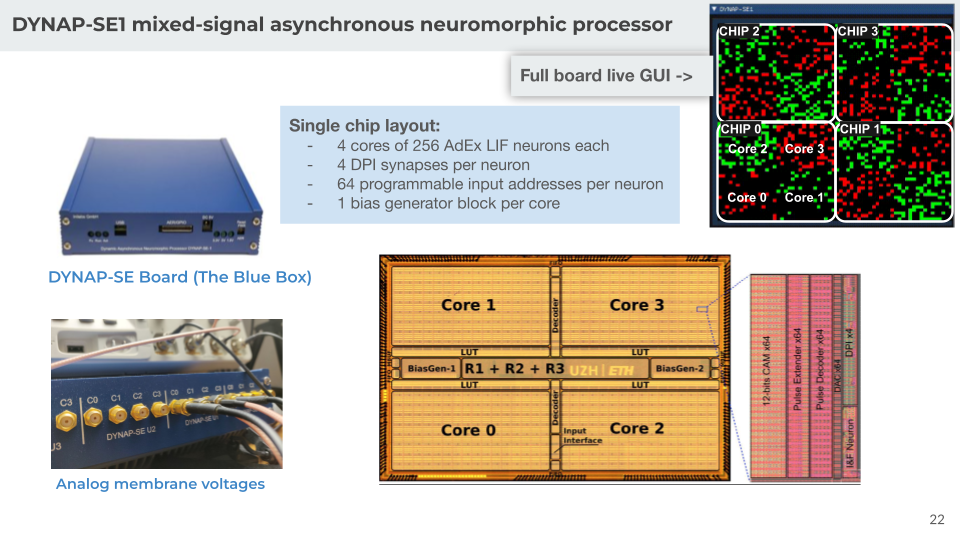

### **Routing**

In the code, a connection between two neurons is created by a single `add_connection()` function, but underneath lie two parts:

**a)** programming of the presynaptic neuron (or "sender") to target the chip of the postsynaptic neuron, and

**b)** programming one of the 64 input slots of the postsynaptic neuron (or "receiver") to listen to the specific presynaptic sender and the synapse type.

Each neuron has:
- 4 SRAMs for target `chip_id` addresses (of which one is used for monitoring, which leaves 3 possible target *chips* for every neurons), and
- 64 CAM cells for addresses encoding the `core_id` and `neuron_id` of the presynaptic neuron (meaning that the postsynaptic neuron *cannot differentiate the spikes of the two presynaptic neurons on two different chips but with the same addresses)* and one of the 4 independent synapse types: AMPA (excitatory), NMDA (excitatory, with optional voltage gating), GABA_A (inhibitory, dendritic) and GABA_B (inhibitory, shunting).

**Important note**: *at initialization, each CAM is defaulted to `core_id=0` and `neuron_id=0`, which means that if any spikes in the system originate from a neuron `(0,0)`, they get routed to **all** unused synapses. Therefore, we advise to avoid using neurons `(0,0)` on the chips or the FPGA to avoid unexpected chip behaviour.*

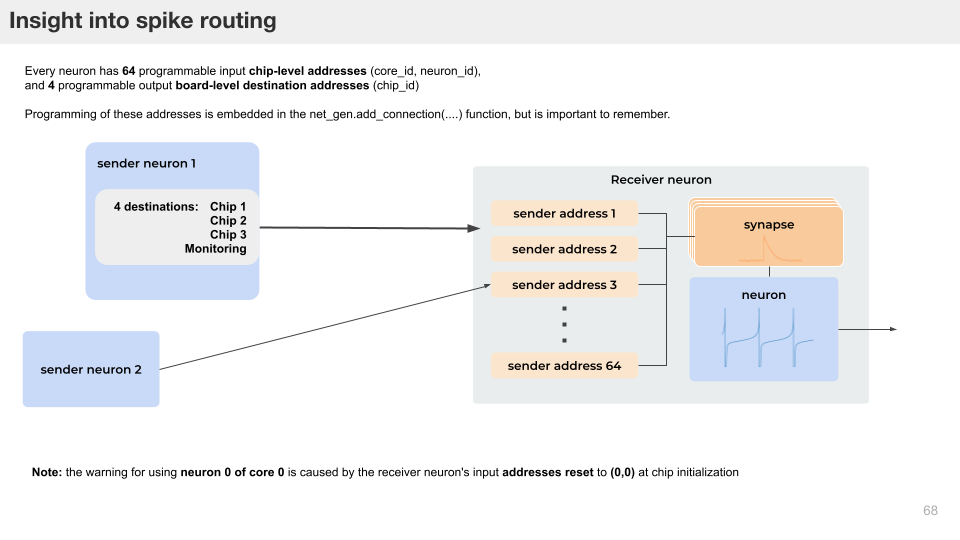

Each of the 4 synapses is implemented as a physical circuit attached directly to the neuron, and the input CAM cells define to which of these synapse circuits the arriving event is routed.

This means, for example, that all input AMPA connections of the neuron influence the dynamics of the same AMPA DPI synapse.

Also, it means that if multiple connections are created between 2 neurons, the same event arrives to the postsynaptic neuron through multiple CAM cells, linearly multiplying its weight.

### **Parameters** (or analog **biases**)

Analog circuits that emulate membrane voltage dynamics of the AdEx LIF neurons and EPSPs and IPSPs of the synapses on DYNAP-SE1 are operating in subthreshold domain of CMOS transistors, modeling the nonlinear dynamics with *currents*.

The circuits are configured by setting gate voltages of the corresponding transistors, controlling properties like leakage (time constant), refractory period, DC input and gain for the neuron, or weight, gain and leakage for synapses (see red arrows with corresponding tags in the figure).

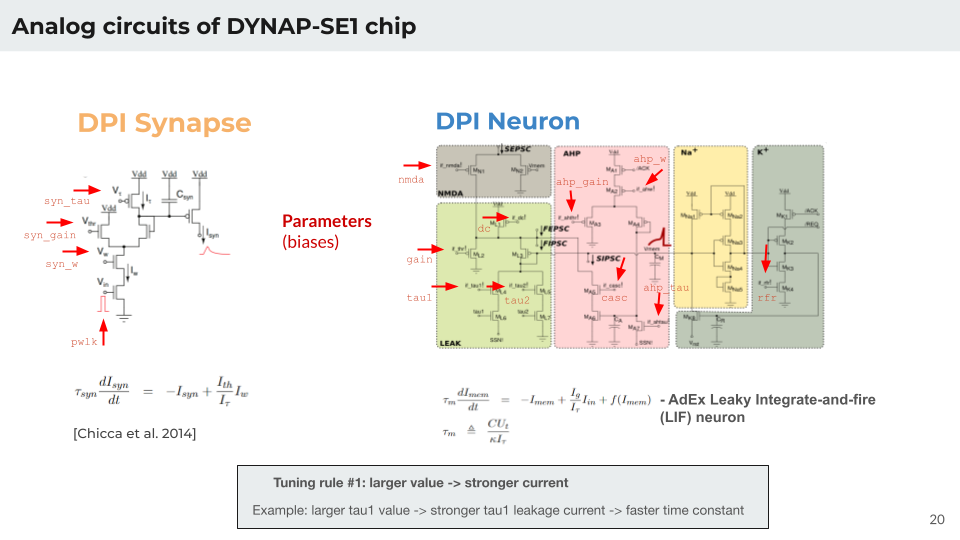


In turn, these voltages are set by the onboard *bias generator* circuits (one for each settable parameter, per core, 25 in total), by generating the corresponding $I_{bias}$ currents that are then applied to all circuits of the core using the shared current mirror. Each settable parameter is shared across all neuron/synapse circuits of the core because of the limited chip area each bias generator circuit requires.

The bias generator's current is set by two registers, controlled by a `coarse` [0...7] and `fine` [0...255] values, that define the proportional output current

$I_{bias}\propto\verb|[fine]|\frac{I_{max}\verb|[coarse]|}{255}$ 

where values of $I_{max}$ are exponentially increasing: $I_{max} = [15,105,820,6.5 \cdot 10^3, 50 \cdot 10^3, 0.4 \cdot 10^6, 3.2 \cdot 10^6, 24 \cdot 10^6] \verb|pA|$.

This results in the `coarse` value defining the slope of the value of $I_{bias}$ along which the `fine` scales linearly.

In the code, parameter setting is simplified by allowing user to set the `linear` value directly which is then rounded to the nearest valide (`coarse`, `fine`) pair, which is why it is important to keep in mind the architecure beneath.

#### **Setting parameters:** `tuple`, `linear` and `index` formats.

Since some combinations of `coarse` and `fine` can genearte the same $I_{bias}$, in the code we use a monotonously increasing look-up table, mapping the `linear` value of $I_{bias}$ to the `tuple` with the highest `coarse` and corresponding `fine` value to allow one continuous parameter set the entire range.

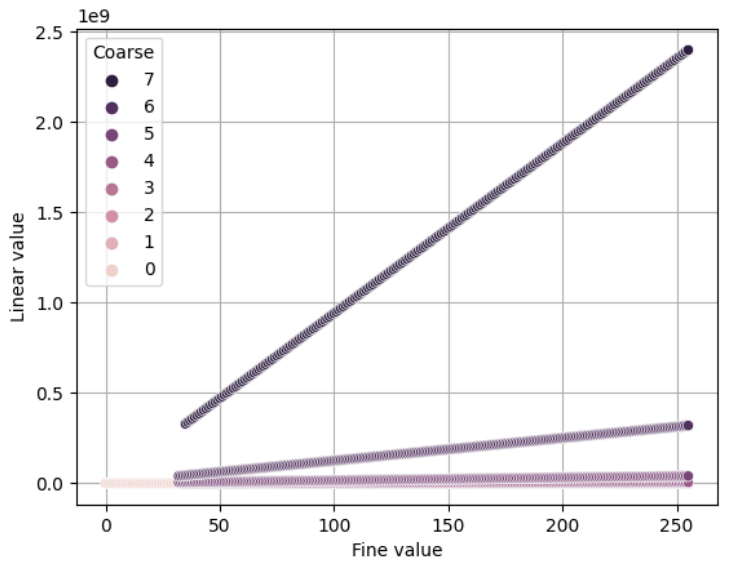

We introduce three formats to set the parameters:

- **`linear`**: a value from 0 to 24e+08, estimated from the bias generator $I_{bias}$  model (equation above). Any relations between parameters (e.g. clamping $I_{gain}$ to $I_\tau$) can be done using this format.
> *Note*: each `linear` value is always rounded to the one corresponding to a `tuple` with the nearest valid value of `fine`, meaning that small increments of `linear` parameter will likely not result in any changes. This also means that the resolution of the `linear` value is much lower for high values (since the corresponding $I_{max}\verb|[coarse]|$ values increase exponentially)

- **`tuple`**: the coarse [0, 7] and fine [0, 255] pair.
> This format can still be used by those who prefer it, while it is less intuitive.

- **`index`**: value from 0 to 1811 which indexes the map between **linear** and **tuple** values.
> This format is the most convenient for any parameter sweeps as it gives direct access to all possible parameter values. The corresponding `linear` value scales exponentially with `index` value, following piece-wise linear regions (or is quasi linear in log-domain, see the Figure below)


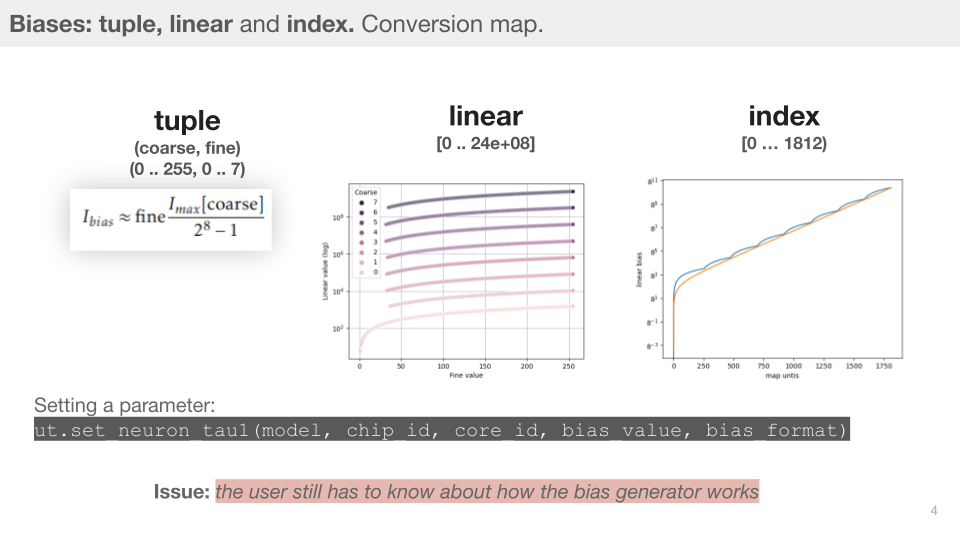


The exact $I_{bias}$ current is impossible to estimate due to mismatch in the bias generator circuits.

Since the values of the parameters we set are dimensionless, the only way to precisely know the resulting property is to observe waveforms using the external oscilloscope and extracting the respective properties (**Tutorial 2** of this repository introduces the tuning process in detail).

If the oscilloscope is not available, the only observable chip output is spikes.

To help, we have some intial reference parameters (that can be loaded from the `parameters` driectory of the repository) as a starting point, from which we can make educated guesses when we change the parameters in either direction.

Below is the example of the typical waveform shapes captured from neuron's voltage during i) firing, ii) subthreshold DC pulse and iii) with leakage turned up to max so that the neuron voltage immediately follows EPSPs\IPSPs (**Tutorial 2** shows the process of this capture).

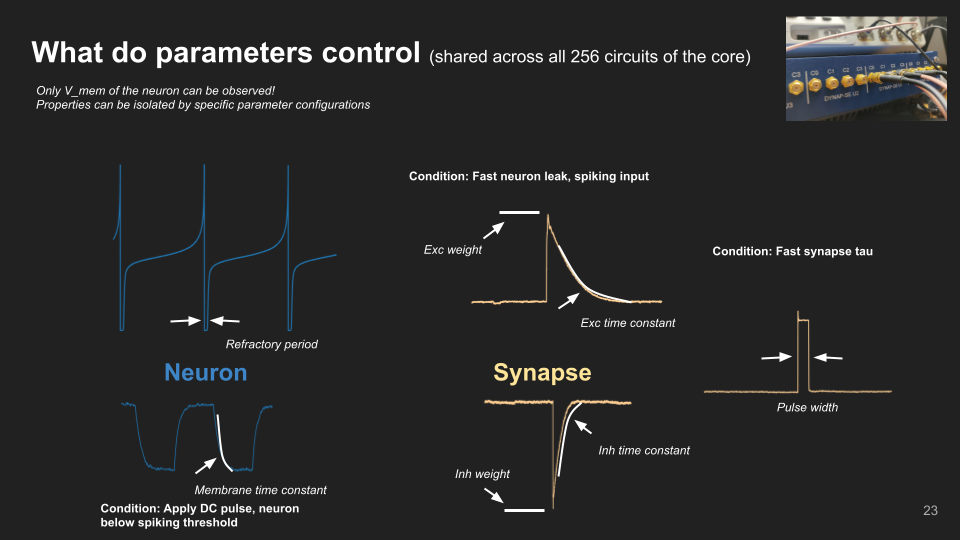

It is possible to set (and get) the parameters either through the corresponding *named functions* (e.g. `set_neuron_tau1(... , param_value)`) or using the generic bias setter/getter with a `param_tag` as an argument (e.g. `set_bias('param_tag', param_value)`).

The `param_tag`s are also used for convenient access of specific parameter is some cases, such as building interactive GUIs.

The full list of parameters controlled by the bias generators on DYNAP-SE1 is the following (also accessible within constants `dynapse1constants.BIAS_TAGS` and `dynapse1constants.BIAS_NAMES_FULL`):

***Neuron parameters***
| param_tag | Description | Setter function | On-chip name |
| --- | --- | --- | --- |
| `'tau1'` | Tau 1 (neuron time constant, default) | `set_neuron_tau1()` | IF_TAU1_N |
| `'tau2'` | Tau 2 (neuron time constant, secondary) | `set_neuron_tau2()` | IF_TAU2_N |
| `'rfr'` | Refractory period (neuron) | `set_neuron_refractory_period()` | IF_RFR_N |
| `'gain'` | Neuron membrane voltage gain | `set_neuron_gain()` | IF_THR_N |
| `'dc'` | DC input level | `set_neuron_dc()` | IF_DC_P |

***Excitatory synapse parameters***
*(NMDA synapse is identical to AMPA unless `nmda` paramter enables voltage gating)*
| param_tag | Description | Setter function | On-chip name |
| --- | --- | --- | --- |
| `'ampa_w'`| AMPA synapse weight | `set_ampa_weight()` | PS_WEIGHT_EXC_F_N |
| `'ampa_tau'`| AMPA synapse time constant | `set_ampa_tau()` | NPDPIE_TAU_F_P |
| `'ampa_gain'`| AMPA synapse gain | `set_ampa_gain()` | NPDPIE_THR_F_P |
| --- | --- | --- | --- |
| `'nmda_w'`| NMDA synapse weight | `set_nmda_weight()` | PS_WEIGHT_EXC_S_N |
| `'nmda_tau'`| NMDA synapse time constant | `set_nmda_tau()` | NPDPIE_TAU_S_P |
| `'nmda_gain'`| NMDA synapse gain | `set_nmda_gain()` | NPDPIE_THR_S_P |
| `'nmda'`| NMDA mechanism enable | `set_nmda_enable()` | IF_NMDA_N |

***Inhibitory synapse parameters***
| param_tag | Description | Setter function | On-chip name |
| --- | --- | --- | --- |
| `'gaba_a_w'`| GABA A synapse weight | `set_gaba_a_weight()` | PS_WEIGHT_INH_F_N |
| `'gaba_a_tau'`| GABA A synapse time constant | `set_gaba_a_tau()` | NPDPII_TAU_F_P |
|` 'gaba_a_gain'`| GABA A synapse gain | `set_gaba_a_gain()` | NPDPII_THR_F_P |
| --- | --- | --- | --- |
| `'gaba_b_w'`| GABA B synapse weight | `set_gaba_b_weight()` | PS_WEIGHT_INH_S_N |
| `'gaba_b_tau'`| GABA B synapse time constant | `set_gaba_b_tau()` | NPDPII_TAU_S_P |
| `'gaba_b_gain'`| GABA B synapse gain | `set_gaba_b_gain()` | NPDPII_THR_S_P |

***Spike-frequency adaptation***
| param_tag | Description | Setter function | On-chip name |
| --- | --- | --- | --- |
| `'ahp_w'`| Adaptation weight | `set_neuron_adaptation_weight()` | IF_AHW_P |
| `'ahp_tau'`| Adaptation time constant | `set_neuron_adaptation_tau()` | IF_AHTAU_N |
| `'ahp_gain'`| Adaptation gain | `set_neuron_adaptation_gain()` | IF_AHTHR_N |
| `'casc'`| Cascode (enable adaptation) | `set_adaptation_enable()` | IF_CASC_N |

***Utility and monitoring***
| param_tag | Description | Setter function | On-chip name |
| --- | --- | --- | --- |
| `'pwlk'` | Spike pulse length | `set_pulse_width()` | PULSE_PWLK_P |
| `'buf'` | V_mem monitoring filter | `set_buf_bias()` | IF_BUF_P |
| `'r2r'` | R2R | `set_r2r_bias()` | R2R_P |

Parameter values can also be saved to *.json *.txt files, therefore the setter functions are intended to manipulate the parameters during the run during tuning or within experiments, followed by saving the set of parameters to a file.

**Note**: *due to mismatch in the bias generator circuits, copying parameters from one core to the other, while generally fine, might lead to quite a different resulting behaviour (the mean of the distribution of the copied parameter across the circuits of the core may shift for more than 1 sigma) of the target core and should be done carefully.*

With these hardware architecture details out of the way, let's look at the software stack that lets us interact with the DYNAP-SE1 board.

---

### **Samna architecture**

**`Samna`** is a proprietary PYPI package that provides Python API to interact with the DYNAP-SE1 board (as well as the other SynSense products).

We interact with the DYNAP-SE1 board through the `model` handle. The DYNAP-SE1 board is *write-only* by design, so the `model` helps to keep track of all the changes from the initialization state we've sent to the board, and also exposes several independent interaction channels:

- **apply/get configurations** (`configuration` object containing connections and parameters returned by `model.get_configuration()` which can be manipulated or generated and applied back to the model with `model.apply_configuration()`)
- **update single parameters** (`model.update_single_parameter(...)`)
- **stream events out** (`Event Graph` process where `model` serves are the source node)
- **export membrane voltages** (using API returned by `model.get_dynapse_api()`)
- **send spiking input** (spike generator objects, returned by `model.get_fpga_spike_gen()` or `model.get_poisson_gen()`)

Additionally, there is a separate connectivity tracking helper object `Network Generator` that populates an empty `configuration` with intended connections (i.e. prepares the instructions for programming CAMs/SRAMs), but is unaware of the `model` state.

Note that in all of these domains the same physical neurons are defined from different perspectives: for keeping track of the connections, `Network Generator` requires creating `Neuron` objects that represent physical units, while for monitoring and spike generation we pass physical IDs of those neurons to the respective functions.

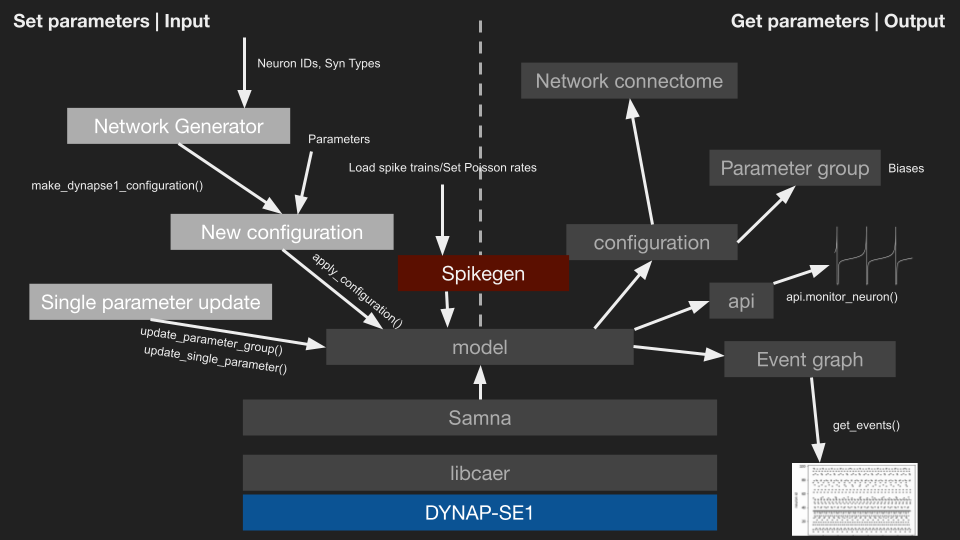


### **Utilities of `dynapse1utils`**

To enhance core functionality, this repository provides an additional set of tools `dynapse1utils` that wraps most of the lower level functions mentioned above with the goal to streamline the workflow.

We normally import `dynapse1utils` as `ut` and use such functionalities as:

***Device access***
- `ut.open_dynapse1(gui=False, select_device)` - list all connected DYNAP-SE1 devices, retrieve the model of the selected one
- `ut.open_gui(model)` - open the native Samna visualizer (for locally connected devices)
- `ut.close_dynapse1(model)` - close the device correctly after usage

***Parameters***
- `ut.set_parameters_in_txt_file(model, filename)` - load parameters from a TXT file (whole board)
- `ut.save_parameters2txt_file(config, filename)` - save parameters to a TXT file (whole board)
- `ut.set_param_group_from_txt_file(model, chip_id, core_id, filename, priority_bias_format)` - load parameters from a TXT file (selected core)
- `ut.save_param_group_to_txt_file(config, chip_id, core_id, filename)` - load parameters to a TXT file (single core)
- `ut.apply_biases_from_configuration(source_config, target_config)` - copy parameters between `configuration`s
- setters and getters for individual parameters (listed above)
- parameter format converters (`ut._bias_as_idx(value, format)`, `ut._bias_as_linear(value, format)`, `ut._bias_as_tuple(value, format)`)

***Device API wrappers***
- `ut.set_neuron_monitor(model, chip_id, core_id, neuron_id)` - connect $V_{mem}$ of the selected neuron to its core's SMA connector

***Output event streaming***
- `ut.create_neuron_select_graph(model, neuron_ids)` - create the `Event Graph` given the neuron ID triplets, returns the `graph`, `filter_node` and `sink_node`

***Input configuration***
- `ut.set_fpga_spike_gen(fpga_spike_gen, spike_times, indices, target_chips, isi_base=900, repeat_mode=False)` - preload a custom spike train

This list is not exhaustive, but covers the majority of use cases, which is enough for our purposes.

---

In the code below, we will cover the basic principles of interacting with all of these components by allocating a small population of 10 neurons and:

- record their activity spontaneously generated with 'default' parameters
- stimulate them with regular rate spike trains and record response
- **TBA** - stimulating them with variable rate spike trains
- measure key neuron characteristics - F-I and F-F curves (or input rate transfer functions)
- experiment with spike-frequency adaptation




## **Step 0. Connect to the DYNAP-SE1 board**

Import all dependencies.

Make sure the notebook is connected to the `dynapse1_kernel` that has the `samna` package installed, running in the `dynap-se1` repository directory.

In [1]:
import samna
import samna.dynapse1 as dyn1

# append the root folder to import from the repository
import sys
sys.path.append('..')

# essential constants for DYNAP-SE1
from dynapse1constants import *

# main DYNAP-SE1 toolkit
import dynapse1utils as ut

# Network Generator helper class
import netgen as n
from netgen import Neuron

# Other standard utilities
import time
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

The `open_dynapse1` function returns the `model` object that lets us interact with the board.

If `select_device` flag is set to True, a prompt would ask for the ID of the DYNAP-SE1 board *in the list of connected boards*
(i.e. this index will always be 0 if only one board is connected)

It is normal for it to run for 1min 20s or so as all of the parameters and connections are being reset.

**Note**: with the flag `select_device=True` you are prompted to select the number of the board in the list (the first board has index 0). Sometimes that list might not get printed correctly until the cell is executed.

In [2]:
model, _ = ut.open_dynapse1(gui=False, select_device=True)

[0]:  Bus 1 Device 5 Dynapse1DevKit serial_number 00000002
Selected device: 00000002
Sender port: tcp://0.0.0.0:45633
Receiver port: tcp://0.0.0.0:59353
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
0 Dynapse1Wrapper created! libcaer init...
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


If the board is connected locally, we can open the native Samna visualizer:

In [ ]:
ut.open_gui(model)

### Load the starting parameters for the board

These parameters would make the neurons fire due to high DC input and low leak.

In [4]:
ut.set_parameters_in_txt_file(model, "parameters/init_biases.txt")

### **Step 1. Record from the neurons with default parameters. Estimate the firing rate of a population.**

In this section, we are going to set up typical monitoring of several firing neurons and sort the recorded spikes.

With the parameters set above, the neurons should be already active without any additional input.

The onboard FPGA lets us stream all of the spikes out of the board through USB. To do that, we are going to set up an **Event Graph**, which runs as a separate process and continuously fetches all events from the board, passes them to the `filter_node` that only keeps the events from the neurons listed by the user, and then stores them in a buffer of the `sink_node`. Once the Event Graph is instantiated, it just continuously runs in the background. Our only interaction with it is requesting spikes from the `sink_node` using the `get_events()` method.

**TODO**: Expand on the difference between the physical neurons, virtual neurons, graph system for monitoring, network generator

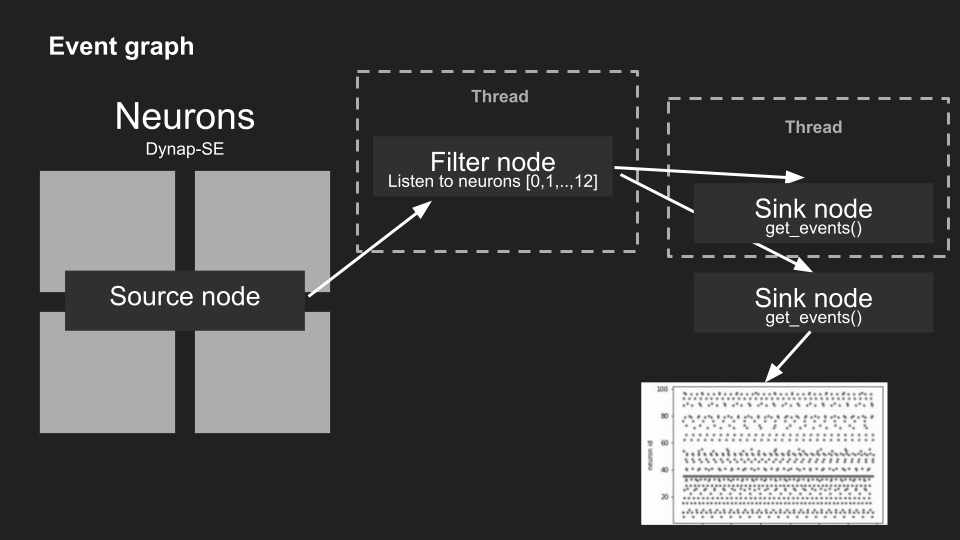


Let's set up the system to stream spikes from of the select neurons, record, sort and plot them.

- Create and configure the `graph` object using `ut.create_neuron_select_graph(model, neurons_to_monitor)` function.
- Start the graph using `graph.start()`
- Use the returned `sink_node` object to access the recorded spikes.

Every time `sink_node.get_events()` is called, is empties the internal buffer and begins a new recording in the background.

**Note:** create only one `graph` instance (i.e. don't rerun the cell many times), every new spawned `graph` process just take more system resources. To change the neurons you monitor you can adjust the filter node using `filter_node.set_neurons(neuron_ids)`

In [5]:
# create triplets of indices of neurons to monitor
chip_id=1
core_id=0

neurons_ids = np.arange(10, 20)

neurons_ids_triplets = [(chip_id, core_id, n_id) for n_id in neurons_ids]
event_graph, filter_node, sink_node = ut.create_neuron_select_graph(model, neurons_ids_triplets)

event_graph.start()


True

To fetch the spikes, we first flush any buffered events collected by `sink_node` by calling `get_events()` without storing any of them (this can be thought as a "beginning of the experiment").

Afterwards, we physically wait the set amount of time and fetch any newly collected events:

In [6]:
# re-run this cell to try recording from different neurons with various parameters

recording_length_s = 5 # seconds

sink_node.get_events() # "reset", simply empties the filter

time.sleep(recording_length_s) # physically wait for the set amount of time

events = sink_node.get_events() # fetch any freshly recorded events

print("Number of recorded events:", len(events))

avg_firing_rate = len(events)/(len(neurons_ids)*recording_length_s) # sum events together and divide by the number of neurons and the recording length
                                                                    # to get the average firing rate in Hz
print(f"Average firing rate: {avg_firing_rate} Hz")


Number of recorded events: 1462
Average firing rate: 29.24 Hz


#### **Plotting**

The most common way to visualize the events is a raster plot: the X-axis is time and Y-axis is the neuron index.

Each recorded event has two values: the neuron ID that emitted it and the timestamp (in microseconds) provided by the chip's onboard FPGA.

To plot them reasonably, we suggest to always subtract the timestamp from the rest.

Text(0, 0.5, 'neuron ID ')

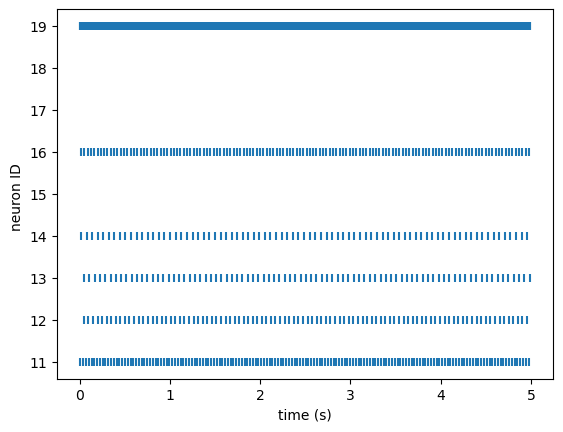

In [7]:
event_ids = np.array([evt.neuron_id for evt in events])
timestamps_us = np.array([evt.timestamp for evt in events])
timestamps_us[:]-=timestamps_us[0]
timestamps_s = timestamps_us*1e-06

plt.scatter(timestamps_s, event_ids, marker='|')
plt.xlabel("time (s)")
plt.ylabel("neuron ID ")


In the plot we should see that some neurons are more active than the others, while some might be completely silent. This is due to very low leaks set for both neurons and synapses, which maximises the mismatch-induced variability of the silicon circuits.

We can plot the average activity of our neuron population by low-pass filtering all of these collected events with an exponential window.

`tools.spikegen_tools` module has the function `get_instantaneous_activity_array` to do exactly that. The additional parameters `activity_dt_s` and `exp_tc_s` define the sampling rate of the resulting trace and the exponential window decay, respectively.

Text(0, 0.5, 'activity, hz')

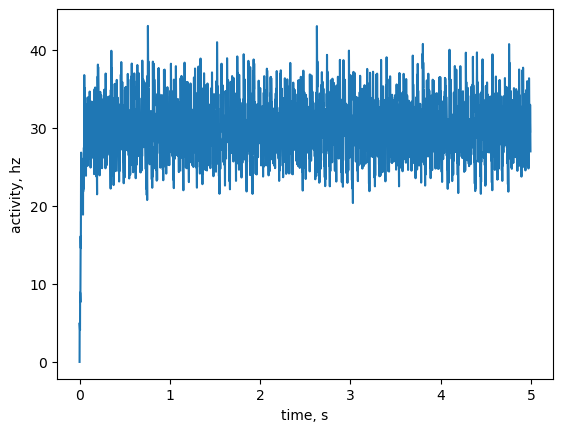

In [9]:
from tools.spikegen_tools import get_instantaneous_activity

#get activity for all neurons together using the merges spiketrain
activity_hz, activity_x = get_instantaneous_activity(timestamps_s, activity_dt_s=0.001, exp_tc_s=0.02)

#normalize the activity measurement by the number of neurons
num_neurons = len(neurons_ids)
plt.plot(activity_x, activity_hz/num_neurons)
plt.xlabel("time, s")
plt.ylabel("activity, hz")

### **Exercise 1**: Measure the F-I curves of multiple neurons at multiple values of neuron time constants.

Record the firing rates as a function of the DC input (or the "F-I" curves).

To do that, let's keep monitoring the group of neurons we used before and automate the change of the DC input using the `ut.set_neuron_dc(model, chip_id, core_id, bias_value, bias_format)` function.

Sweep the linear `bias_value` value so that the neurons change their frequency from 0 to around 300 Hz.

Plot the firing rates for individual neurons, as well the mean and the variance for each value of input. This should show the built-in variability of analog neuron circuits - the coefficient of variation of rates should be around 10-20%.

In [10]:
dc_min = 0 # minimum DC input (linear parameter format)
dc_max = 22e+08 # maximum DC input (linear parameter format)
dc_step = 1e+08 # increment

recording_length_s = 0.5 # seconds

recorded_rates = []
num_neurons = len(neurons_ids)
# sweep fine value and capture events as shown above
# (could also be put inside of a function)

for dc_value in np.arange(dc_min, dc_max, dc_step):
    print(f"Recording rates for dc_paramter={dc_value}...")
    
    ut.set_neuron_dc(model, chip_id, core_id, int(dc_value), bias_format='linear')
    
    sink_node.get_events() # "reset", simply empties the filter
    time.sleep(recording_length_s) # physically wait for the set amount of time
    events = sink_node.get_events()
    
    avg_firing_rate = len(events)/(len(neurons_ids)*recording_length_s)
    
    rates = dict.fromkeys(neurons_ids, 0)
    if len(events) > 0:
        for evt in events:
            rates[evt.neuron_id]+=1
        # convert event counts to individual rates by dividing them
        # by the time interval
        for n_id, evt_count in rates.items():
            rates[n_id]=evt_count/recording_length_s
            
    recorded_rates.append(rates)
        
ut.set_neuron_dc(model, chip_id, core_id, int(0), bias_format='index')

Recording rates for dc_paramter=0.0...
Recording rates for dc_paramter=100000000.0...
Recording rates for dc_paramter=200000000.0...
Recording rates for dc_paramter=300000000.0...
Recording rates for dc_paramter=400000000.0...
Recording rates for dc_paramter=500000000.0...
Recording rates for dc_paramter=600000000.0...
Recording rates for dc_paramter=700000000.0...
Recording rates for dc_paramter=800000000.0...
Recording rates for dc_paramter=900000000.0...
Recording rates for dc_paramter=1000000000.0...
Recording rates for dc_paramter=1100000000.0...
Recording rates for dc_paramter=1200000000.0...
Recording rates for dc_paramter=1300000000.0...
Recording rates for dc_paramter=1400000000.0...
Recording rates for dc_paramter=1500000000.0...
Recording rates for dc_paramter=1600000000.0...
Recording rates for dc_paramter=1700000000.0...
Recording rates for dc_paramter=1800000000.0...
Recording rates for dc_paramter=1900000000.0...
Recording rates for dc_paramter=2000000000.0...
Recording 

Text(0, 0.5, 'Mean Firing Rate')

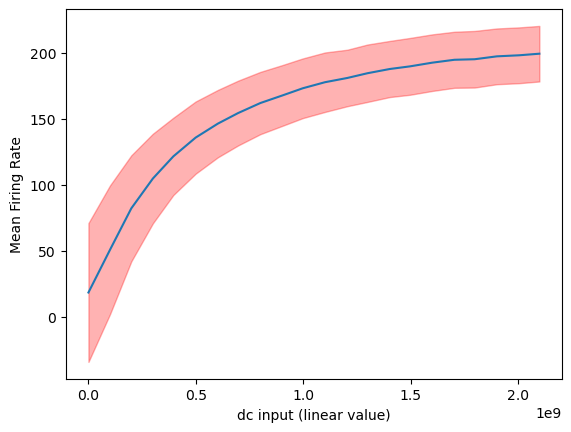

In [11]:
# Example code for processing rates

x_labels = [ut._bias_as_linear(int(dc_value), 'linear') for dc_value in np.arange(dc_min, dc_max, dc_step)]
mean_y_labels = []
std_y_labels = []

for line, fine in zip(recorded_rates, x_labels):
    rates = np.fromiter(line.values(), dtype=float)
    mean_rate = rates.mean()
    std_rate = rates.std()
    mean_y_labels.append(mean_rate)
    std_y_labels.append(std_rate)
    
plt.figure()
plt.plot(x_labels, mean_y_labels)
plt.fill_between(x_labels,np.array(mean_y_labels)- np.array(std_y_labels), np.array(mean_y_labels) + np.array(std_y_labels), alpha = 0.3, color = 'red')
plt.xlabel('dc input (linear value)')
plt.ylabel('Mean Firing Rate')
#plt.savefig("average_rate_vs_fine.png")

### **Step 2: Send spike patterns to the population of neurons.**

Connecting neurons and sending input is done independently from recording and monitoring.

To send events to the silicon neuron from the FPGA, the receiving neurons need to be programmed to listen to the correct sources.
The connectivity matrix is handled by the `Network Generator` object, and we need to point at the neurons we are already monitoring to create connections from the spike generators.

![DYNAP-SE1 _fpga_input.png](<attachment:DYNAP-SE1 _fpga_input.png>)

To do that, we allocate physical and virtual (FPGA) neurons by creating representative `Neuron` objects for the `Network Generator` and create specific excitatory (AMPA) one-to-one connections.

The virtual neurons always sit on the Chip 0, and have to use the flag `is_spike_gen=True` when allocated as `Neuron` objects.
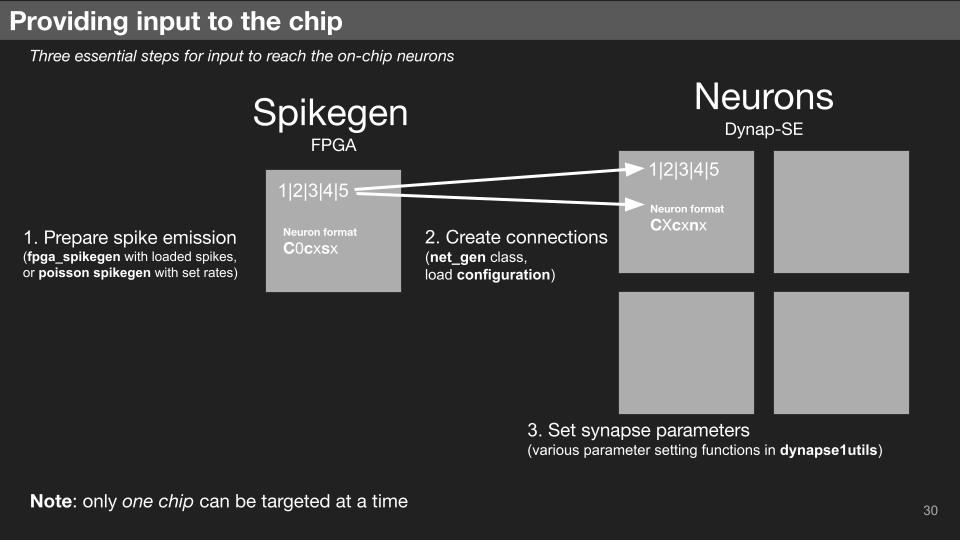

In [12]:
chip_id=1
core_id=0

# Allocate the input and the target populations to connect.
# The target physical population should be the same one that we monitor from with the Event Graph.

virtual_neurons_ids = np.arange(10, 20)
physical_neurons_ids = np.arange(10, 20)

virtual_neurons = [Neuron(0,0,n_id,is_spike_gen=True) for n_id in virtual_neurons_ids]
physical_neurons = [Neuron(chip_id,core_id,n_id) for n_id in physical_neurons_ids]

connection_type = samna.dynapse1.Dynapse1SynType.AMPA

net_gen = n.NetworkGenerator()

for v_neuron, p_neuron in zip(virtual_neurons, physical_neurons):
    for i in range(2): # we can repeat every input connection twice for double stength
        net_gen.add_connection(v_neuron, p_neuron, connection_type)
        
# all of these connections are registered within the Network Generator
# let's confirm that the network configuration looks correct:
# physical neurons (labelled as Cxcxnx) receive inputs from virtual neurons (Cxcxsx) of the correct type  
print(net_gen.network)

Post neuron (ChipId,coreId,neuronId): incoming connections [(preNeuron,synapseType), ...]
C1c0n10: [('C0c0s10', 'AMPA'), ('C0c0s10', 'AMPA')]
C1c0n11: [('C0c0s11', 'AMPA'), ('C0c0s11', 'AMPA')]
C1c0n12: [('C0c0s12', 'AMPA'), ('C0c0s12', 'AMPA')]
C1c0n13: [('C0c0s13', 'AMPA'), ('C0c0s13', 'AMPA')]
C1c0n14: [('C0c0s14', 'AMPA'), ('C0c0s14', 'AMPA')]
C1c0n15: [('C0c0s15', 'AMPA'), ('C0c0s15', 'AMPA')]
C1c0n16: [('C0c0s16', 'AMPA'), ('C0c0s16', 'AMPA')]
C1c0n17: [('C0c0s17', 'AMPA'), ('C0c0s17', 'AMPA')]
C1c0n18: [('C0c0s18', 'AMPA'), ('C0c0s18', 'AMPA')]
C1c0n19: [('C0c0s19', 'AMPA'), ('C0c0s19', 'AMPA')]



To apply this network to the chip, we generate the `configuration` and apply it to the `model`.

Since we generate the `configuration` object from scratch using the `Network Generator`, and it also contains some default parameter values, we need to update the parameters within the new configuration before sending it to the chip by copying them from the configuration freshly retrieved from the `model`.

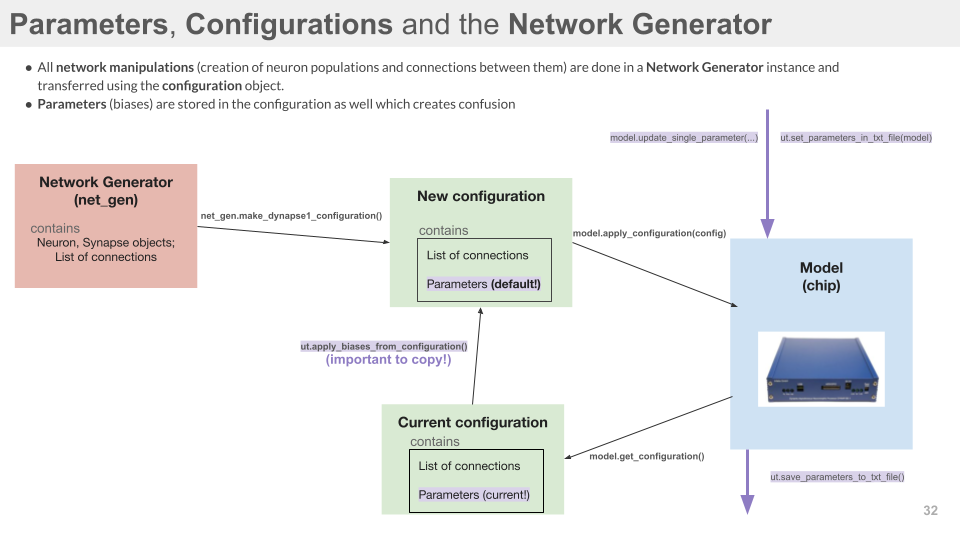


To do that, `dynapse1utils` has a dedicated function `ut.apply_biases_from_configuration(source_config, target_config)`.

We advise to do this step every time any connections are updated.

In [13]:
new_config = net_gen.make_dynapse1_configuration()
ut.apply_biases_from_configuration(model.get_configuration(), new_config)
model.apply_configuration(new_config)

New configuration applied to DYNAP-SE1!


Now the AMPA connections should be created between the virtual and the physical neurons.

To see the their effect we now need to do two more steps:
1. make the virtual neurons emit events
2. set the AMPA synapse parameters such that the generated EPSPs result in firing of the physical neurons


#### **Generating the input spike sequence**

**TODO**: explain spiketrain limitations from the original demo. Add demo for the time varying input and Poisson

Text(0, 0.5, 'spikegen')

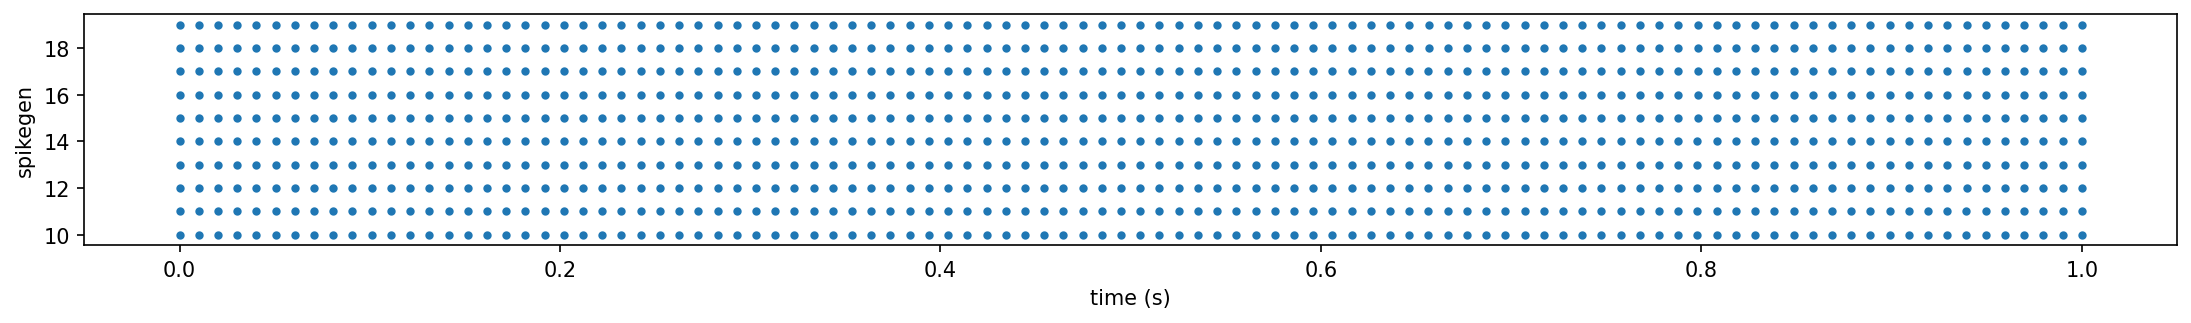

In [14]:
from tools.spikegen_tools import generate_regular_rate_spiketrain

# prepare the spike train that the spike generators will fire

# in our case it will be a sequence of spikes at a fixed rate:
spikegen_regular_rate = 100 #Hz

rates_vector = (spikegen_regular_rate*np.ones(len(neurons_ids))).astype(int)


# generate a spiketrain
fpga_spiketrain = generate_regular_rate_spiketrain(rates_vector, neurons_ids)


# plot the prepared spiketrain to verify it is correct
plt.figure(figsize=(18,2), dpi=150)
plt.plot(fpga_spiketrain[:,0], fpga_spiketrain[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

To load the spiketrain to the FPGA use the function `ut.set_fpga_spike_gen()`

TODO: Add introduction into FPGA logic - targets one chip at a time, spiketrain encoded as ISIs, so we use dummy spikes to fill the gaps

In [15]:
fpga_spike_gen = model.get_fpga_spike_gen()
target_chip = chip_id # should be the same where _physical_neurons are located
fpga_spike_gen.stop()

ut.set_fpga_spike_gen(fpga_spike_gen,
                      spike_times=fpga_spiketrain[:,0],
                      indices=fpga_spiketrain[:,1].astype(int),
                      target_chips=[target_chip]*len(fpga_spiketrain),
                      isi_base=900,
                      repeat_mode=True)

# start the playback of the uploaded spike train
fpga_spike_gen.start()

FpgaSpikeGen already off!


In [24]:
fpga_spike_gen.stop()

**TODO**: Add the time varying input section here

Configure the AMPA synapse biases to transmit spikes to the neurons

- lower or remove the DC input
- set AMPA synapse weight to a high value (7, 200)
- set AMPA synapse threshold to (6, 100)
- set AMPA synapse time constant to (3, 100)

To confirm the spikes are received by the physical neurons, set the neuron time constant (tau1) to a high value using the bias GUI, increading the leak and thus making V_mem follow the synaptic input. Once the fixed rate pulses are observed, tune the synaptic time constant to around 20-30ms.

Then return to the neuron time constant back to "normal"

In [16]:
#TODO swith these values to index or linear?

# turn DC off
ut.set_neuron_dc(model, chip_id, core_id, 0, 'index')

# set the AMPA synapse parameters - gain, weight and decay.
ut.set_ampa_gain(model, chip_id, core_id, (6, 100))
ut.set_ampa_weight(model, chip_id, core_id, 1700, 'index')
ut.set_ampa_tau(model, chip_id, core_id, (3, 100))

In [17]:
# set neuron decay and gain
ut.set_neuron_tau1(model, chip_id, core_id, (4, 220))
ut.set_neuron_gain(model, chip_id, core_id, (0, 50))

**TODO: Add section changing parameters to see the spikes**

Now that we see the spiking input arrives to the chip, we can measure the frequency responses of the neurons

#### **Excercise 2:** Measure F-F curves of the neurons and plot the recorded rates

Similarly to the F-I curves, we now have all the tools to take the F-F curves of our silicon neurons.

This time, we will keep all of the analog parameters fixed and only increment the input firing rate.

In a sweep from 10 Hz to 600 Hz we will generate and preload the regular rate spike train, then send it to the chip for the duration of 1 second, and process the recording.

In [ ]:
# Example F-F curve measurement
recording_length_s = 1

rate_min = 10 #Hz
rate_max = 400 #Hz
rate_step = 10 #Hz
recorded_rates = []

for rate in np.arange(rate_min, rate_max, rate_step):
    
    rates_vector = (rate*np.ones(len(neurons_ids))).astype(int)
    
    # prepare the spiketrain
    fpga_spiketrain = generate_regular_rate_spiketrain(rates_vector, neurons_ids)
    
    # stop the spikegen while it is being reset
    fpga_spike_gen.stop()
    ut.set_fpga_spike_gen(fpga_spike_gen,
                      spike_times=fpga_spiketrain[:,0],
                      indices=fpga_spiketrain[:,1].astype(int),
                      target_chips=[target_chip]*len(fpga_spiketrain),
                      isi_base=900,
                      repeat_mode=True)
    
    # start the spikegen with the new spiketrain
    fpga_spike_gen.start()
    
    # record and sort events
    sink_node.get_events() # "reset", simply empties the filter
    time.sleep(recording_length_s) # physically wait for the set amount of time
    events = sink_node.get_events()
    
    avg_firing_rate = len(events)/(len(neurons_ids)*recording_length_s)
    print(f"Input rate: {rate} Hz")
    print(f"Average firing rate: {avg_firing_rate} Hz")
    
    rates = dict.fromkeys(neurons_ids, 0)
    if len(events) > 0:
        for evt in events:
            rates[evt.neuron_id]+=1
        # convert event counts to individual rates by dividing them
        # by the time interval
        for n_id, evt_count in rates.items():
            rates[n_id]=evt_count/recording_length_s
            
    recorded_rates.append(rates)
    

VariableIsiMode already 1
RepeatMode already 1
Input rate: 10 Hz
Average firing rate: 11.7 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 20 Hz
Average firing rate: 19.9 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 30 Hz
Average firing rate: 29.0 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 40 Hz
Average firing rate: 39.0 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 50 Hz
Average firing rate: 49.0 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 60 Hz
Average firing rate: 59.0 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 70 Hz
Average firing rate: 68.8 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 80 Hz
Average firing rate: 71.8 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 90 Hz
Average firing rate: 79.2 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 100 Hz
Average firing rate: 89.0 Hz
VariableIsiMode already 1
RepeatMode already 1
Input rate: 

Let's plot the obtained F-F curves and estimate the variability between the neurons.

With higher input rates the F-F curves should saturate, but not drop. If a decrease in firing rate is observed for higher firing rates, it is likely caused by the digital router overflow by too many simulateous events. To address that, sometimes it helps to reduce the size of the observed population, or even measure neurons one by one. Events from other cores or chips might also interfere with the available bandwidth of the router. 

Text(0, 0.5, 'Mean Firing Rate')

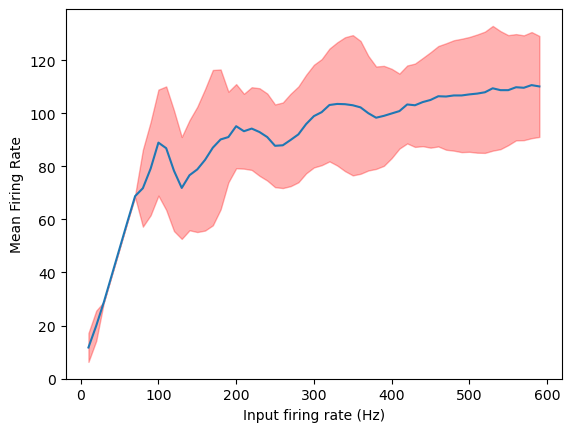

In [19]:
## store and plot the firing rate recordings

x_labels = np.arange(rate_min, rate_max, rate_step)
mean_y_labels = []
std_y_labels = []

for line, fine in zip(recorded_rates, x_labels):
    rates = np.fromiter(line.values(), dtype=float)
    #print(line.values())
    mean_rate = rates.mean()
    std_rate = rates.std()
    mean_y_labels.append(mean_rate)
    std_y_labels.append(std_rate)
    
plt.figure()
plt.plot(x_labels, mean_y_labels)
plt.fill_between(x_labels,np.array(mean_y_labels)- np.array(std_y_labels), np.array(mean_y_labels) + np.array(std_y_labels), alpha = 0.3, color = 'red')
plt.xlabel('Input firing rate (Hz)')
plt.ylabel('Mean Firing Rate')


### **Exercise 3**: Observe spike-frequency adaptation when sending a fixed frequency burst

In this excercise we will observe the action of an additional regulatory mechanism of the silicon neuron - spike-frequency adaptation. This mechanism makes the neuron "less sensitive" or "adapted" to the input it is receiving continuosly.

To observe this, we first need to configure the setup:

- Send fixed-rate pulses (instead of constant firing rates) to observe the neurons' responses.
- Set the auxilary `IF_CASC_N` parameter to a fixed value to enable the adaptaion circuit
- Play with the adaptation weight, threshold and time constant to observe clear adaptation effect

- Record the resulting raster plot and activity.

In [20]:
# Enable the adaptation circuit
ut.set_adaptation_enable(model, chip_id, core_id, 1716, bias_format='index')

# Set the adaptation parameters - decay, weight and gain
ut.set_neuron_adaptation_tau(model, chip_id, core_id, 987, bias_format='index')
ut.set_neuron_adaptation_weight(model, chip_id, core_id, 1666, bias_format='index')
ut.set_neuron_adaptation_gain(model, chip_id, core_id, 1037, bias_format='index')

Preload the 300 Hz input spiketrain for our existing setup from the **Excercise 2**

In [21]:
rate = 300 #hz

rates_vector = (rate*np.ones(len(neurons_ids))).astype(int)
fpga_spiketrain = generate_regular_rate_spiketrain(rates_vector, neurons_ids)

# stop the spikegen while it is being reset
fpga_spike_gen.stop()
ut.set_fpga_spike_gen(fpga_spike_gen,
                  spike_times=fpga_spiketrain[:,0],
                  indices=fpga_spiketrain[:,1].astype(int),
                  target_chips=[target_chip]*len(fpga_spiketrain),
                  isi_base=900,
                  repeat_mode=False)


VariableIsiMode already 1


Automate the spike generator to send pulses of the preloaded spiketrain by using `repeat_mode=False` and switching the spike generator after the length of our spiketrain.

While we can only record spikes from the chip, we should be able to observe the corresponding traces on the oscilloscope

Text(0, 0.5, 'neuron ID ')

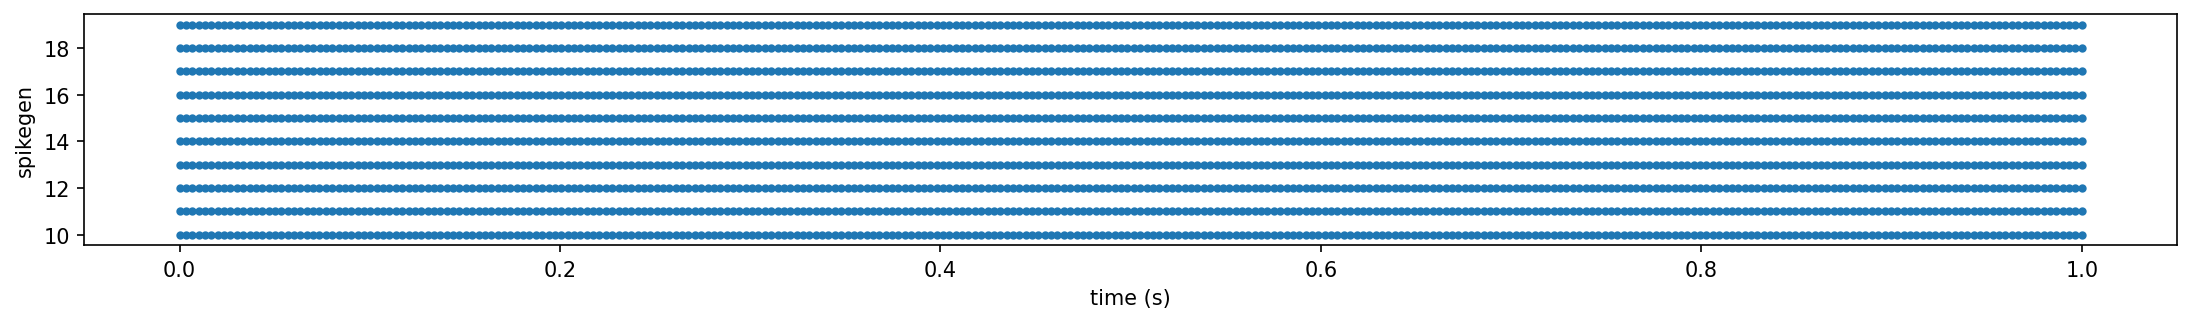

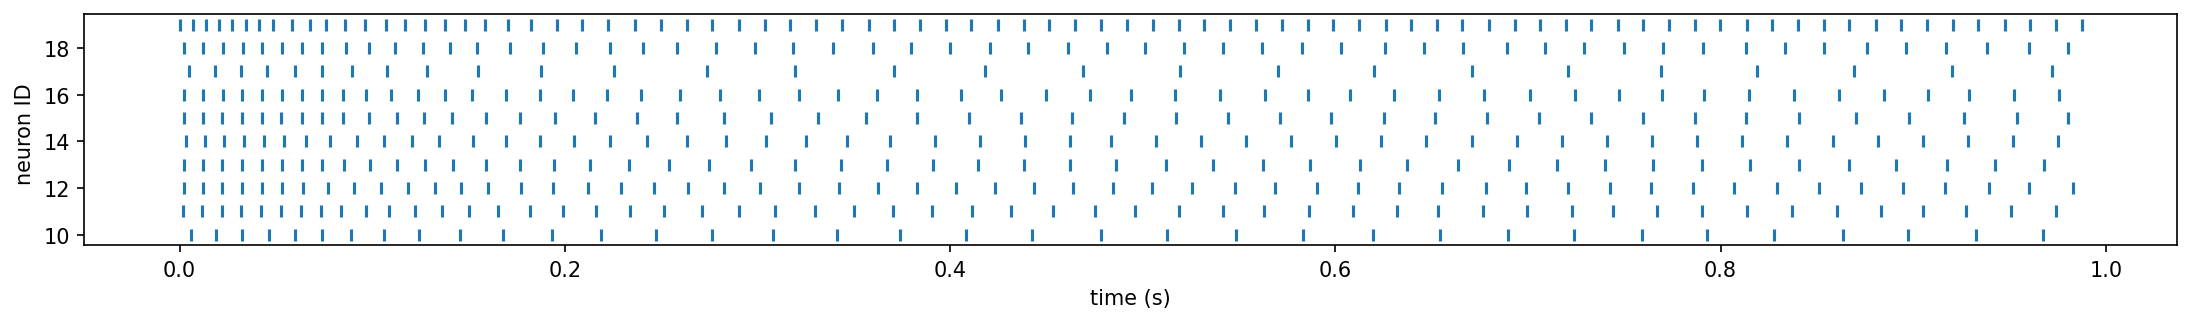

In [22]:
pre_stim_time=0.0 #s
stim_time=1 #s
post_stim_time=0 #s

#ut.set_neuron_adaptation_tau(model, chip_id, core_id, (4, 110))
#ut.set_neuron_adaptation_weight(model, chip_id, core_id, (7, 110))
#ut.set_neuron_adaptation_threshold(model, chip_id, core_id, (4, 150))

#reset the recording
sink_node.get_events()

#wait for any dynamics to stabilize
time.sleep(pre_stim_time)

#start the pulse
fpga_spike_gen.start()
time.sleep(stim_time)

#stop the pulse
fpga_spike_gen.stop()

# wait a bit more after the stimulus is off
time.sleep(post_stim_time)

#get_the events
events = sink_node.get_events()

# sort and plot the events
event_ids = np.array([evt.neuron_id for evt in events])
timestamps_us = np.array([evt.timestamp for evt in events])
timestamps_us[:]-=timestamps_us[0]
timestamps_s = timestamps_us*1e-06


plt.figure(figsize=(18,2), dpi=150)
plt.plot(fpga_spiketrain[:,0], fpga_spiketrain[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

plt.figure(figsize=(18,2), dpi=150)
plt.scatter(timestamps_s, event_ids, marker='|')
plt.xlabel("time (s)")
plt.ylabel("neuron ID ")

Plotting the instantaneous firing acitivity confirming that SFA works

Text(0, 0.5, 'Activity (Hz)')

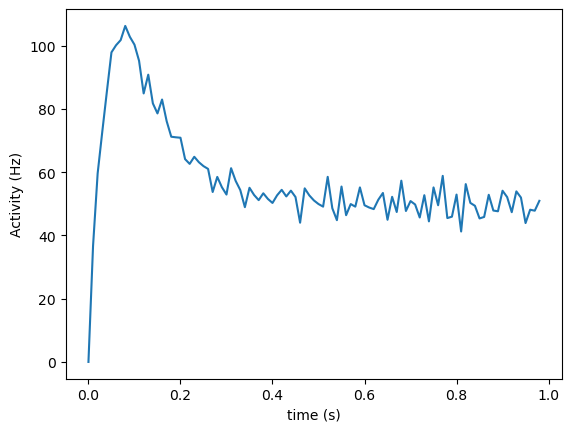

In [24]:
activity_dt = 0.01 #s
exp_time_constant = 0.03 #s

activity, activity_t = get_instantaneous_activity(timestamps_s,
                                                        activity_dt,
                                                        exp_time_constant)

activity = activity/len(neurons_ids)

plt.plot(activity_t, activity)
plt.xlabel("time (s)")
plt.ylabel("Activity (Hz)")

### **Conclusion**

This tutorial has covered the basic interaction with the DYNAP-SE1 board and introduced the core functionalities:
- connecting to the DYNAP-SE1 board
- recording and sorting spikes
- loading and setting parameters
- sending spiking inputs

**Tutorial 2** notebook in the `tutorials` directory of this repository will go in detail over parameter tuning using the oscilloscope measurements.

**Tutorial 3** introduces some Network Primitives that build on top of the functionalities covered in this tutorial, simplifying the chip interactions.

